In [3]:
import os
from typing import Optional, Callable, List
import numpy as np
import torch
from torch.utils.data import Dataset

class NpyImageDataset(Dataset):
    def __init__(self,
                 folder: str,
                 file_list: Optional[List[str]] = None,
                 transform: Optional[Callable] = None,
                 preload: bool = False,
                 mmap_mode: Optional[str] = None):

        self.folder = folder
        if file_list is None:
            self.files = sorted([f for f in os.listdir(folder) if f.endswith('.npy')])
        else:
            self.files = file_list
        if len(self.files) == 0:
            raise ValueError(f"No .npy files found in {folder}")
        self.transform = transform
        self.preload = preload
        self.mmap_mode = mmap_mode

        self._data = None
        if self.preload:
            self._data = [self._load_npy(os.path.join(self.folder, f)) for f in self.files]

    def __len__(self):
        return len(self.files)

    def _load_npy(self, path: str) -> torch.Tensor:
        arr = np.load(path, mmap_mode=self.mmap_mode) if self.mmap_mode else np.load(path)
        arr = np.asarray(arr)
        if arr.ndim == 3:
            if arr.shape[0] == 2:
                arr_cfirst = arr
            elif arr.shape[-1] == 2:
                arr_cfirst = np.moveaxis(arr, -1, 0)
            else:
                arr_cfirst = arr
        elif arr.ndim == 2:
            arr_cfirst = arr[None, ...]
        else:
            raise ValueError(f"Unsupported array shape {arr.shape} in file {path}")

        if arr_cfirst.dtype != np.float32:
            arr_cfirst = arr_cfirst.astype(np.float32)

        tensor = torch.from_numpy(arr_cfirst)
        return tensor

    def __getitem__(self, idx):
        if self.preload:
            tensor = self._data[idx]
        else:
            path = os.path.join(self.folder, self.files[idx])
            tensor = self._load_npy(path)

        if self.transform is not None:
            tensor = self.transform(tensor)

        return tensor


## Config


In [4]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    train_batch_size = 16
    eval_batch_size = 8
    num_epochs = 100
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = 'bf16'
    push_to_hub = False
    seed = 0
    output_dir = 'flow_matching'

config = TrainingConfig()

## Loading the dataset

In [8]:
CHANNEL_MEAN = [0.1382167, 0.1816227]
CHANNEL_STD  = [0.32978467, 0.51380478]

def channel_normalize(x: torch.Tensor) -> torch.Tensor:
    mean = torch.as_tensor(CHANNEL_MEAN, device=x.device, dtype=x.dtype).view(-1, 1, 1)
    std  = torch.as_tensor(CHANNEL_STD,  device=x.device, dtype=x.dtype).view(-1, 1, 1)
    return (x - mean) / std


In [9]:
dataset = NpyImageDataset(
    folder='/data/processed_ice_data_valid',
    transform=channel_normalize,
    preload = False,
    mmap_mode = 'r'
)

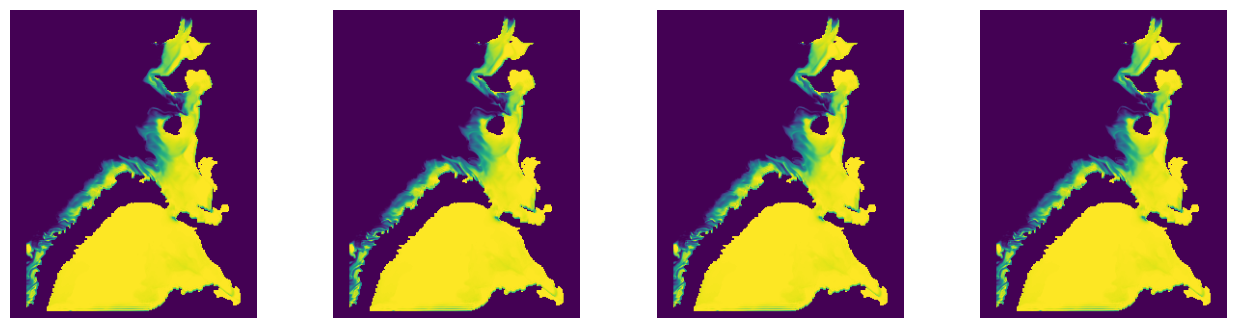

In [10]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    image = dataset[i]
    axs[i].imshow(image[0])
    axs[i].set_axis_off()


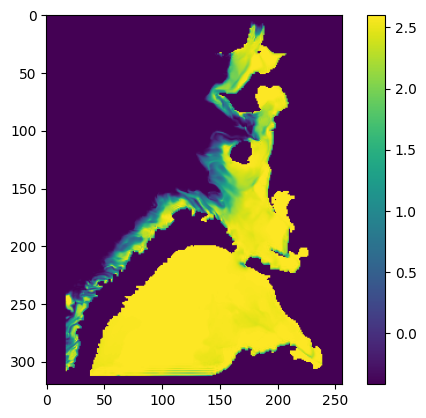

In [11]:
plt.imshow(dataset[0][0])
plt.colorbar()
plt.show()

In [12]:
dataset[0][0].shape

torch.Size([320, 256])

In [13]:
import torch

train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=config.train_batch_size, shuffle=True)

## Model

In [14]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=(320, 256),
    in_channels=4,
    out_channels=2,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [15]:
def make_normalized_xy_grid(
    H: int = 320,
    W: int = 256,
    batch_size: int = config.train_batch_size,
    device='cuda',
    dtype: torch.dtype = torch.float32,
):
    ys = torch.linspace(0.0, 1.0, H, device=device, dtype=dtype)
    xs = torch.linspace(0.0, 1.0, W, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")

    grid = torch.stack([xx, yy], dim=0)
    mean = 0.5
    std = np.sqrt(1.0 / 12.0)
    grid = (grid - mean) / std

    grid = grid.unsqueeze(0).expand(batch_size, -1, -1, -1)

    return grid


In [16]:
sample_image = dataset[0].unsqueeze(0)
print('Input shape:', sample_image.shape)

Input shape: torch.Size([1, 2, 320, 256])


In [17]:
grid = make_normalized_xy_grid(batch_size = 1, device = 'cpu')
print('Output shape:', model(torch.cat([sample_image, grid], dim = 1), timestep=0).sample.shape)

Output shape: torch.Size([1, 2, 320, 256])


## Defining the noise scheduler

In [18]:
def add_noise(images: torch.Tensor, timesteps):
  timesteps = timesteps.view(-1, *([1]*(images.dim() - 1)))
  eps = torch.randn_like(images)
  noisy_images = (1 - timesteps) * images + timesteps * eps

  return noisy_images, eps - images

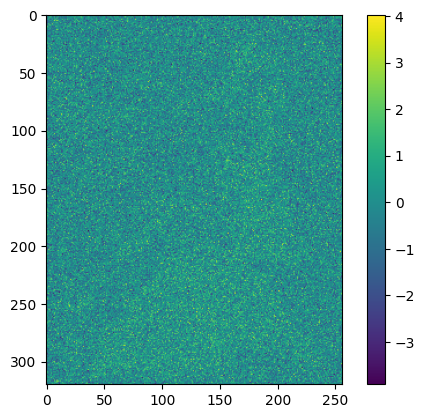

In [19]:
timesteps = torch.tensor([0.9])
noisy_image, eps = add_noise(sample_image, timesteps)

plt.imshow(noisy_image[0, 0])
plt.colorbar()
plt.show()


In [20]:
sample_image.shape

torch.Size([1, 2, 320, 256])

In [21]:
N_images = 10
sample_images = [sample_image for _ in range(N_images)]
sample_images = torch.cat(sample_images, dim=0)
sample_images.shape

torch.Size([10, 2, 320, 256])

In [22]:
timesteps = torch.tensor([i/10 for i in range(1, 11)])
noisy_images, eps = add_noise(sample_images, timesteps)

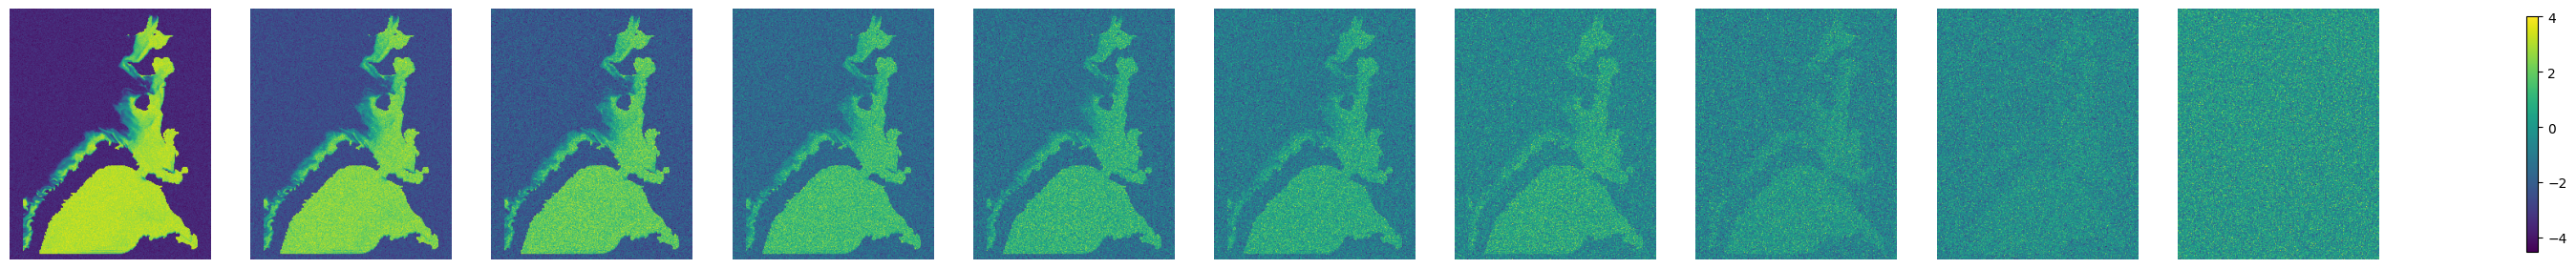

In [23]:
imgs = noisy_images[:,0].detach().cpu().numpy()
fig, axes = plt.subplots(1, len(imgs), figsize=(4*len(imgs), 4))
if len(imgs) == 1: axes = [axes]
for ax, im_arr in zip(axes, imgs):
    im = ax.imshow(im_arr)
    ax.axis('off')
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


## Training setup

In [24]:
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [25]:
from diffusers.optimization import get_cosine_schedule_with_warmup

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

In [26]:
grid_eval = make_normalized_xy_grid(batch_size = 1)
@torch.no_grad()
def evaluate(model, num_timesteps, batch_size):
  grid = grid_eval.expand(batch_size, -1, -1, -1)
  timesteps = [float(i)/num_timesteps for i in range(num_timesteps, 0, -1)]
  x = torch.randn((batch_size, 2, 320, 256), device = 'cuda')
  for i in timesteps:
    x -= float(1/num_timesteps)*model(torch.cat([x, grid], dim = 1), torch.tensor(i, device = 'cuda').expand(batch_size)*1000).sample
  return x


In [27]:
grid_train = make_normalized_xy_grid(batch_size = 1)
grid_train.shape

torch.Size([1, 2, 320, 256])

In [28]:
import os
from pathlib import Path
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration
from diffusers.training_utils import EMAModel

def save_extra_files(unwrapped_model, ema_model, save_dir, epoch, global_step):
    os.makedirs(save_dir, exist_ok=True)
    torch.save(unwrapped_model.state_dict(), os.path.join(save_dir, "model_state.pth"))
    torch.save(ema_model.state_dict(), os.path.join(save_dir, "ema_state.pth"))
    torch.save({"epoch": epoch, "global_step": global_step}, os.path.join(save_dir, "training_state.pt"))

def load_extra_files(unwrapped_model, ema_model, save_dir, map_location="cpu"):
    model_path = os.path.join(save_dir, "model_state.pth")
    ema_path = os.path.join(save_dir, "ema_state.pth")
    training_state_path = os.path.join(save_dir, "training_state.pt")

    if os.path.isfile(model_path):
        sd = torch.load(model_path, map_location=map_location)
        unwrapped_model.load_state_dict(sd)
    if os.path.isfile(ema_path):
        sd = torch.load(ema_path, map_location=map_location)
        ema_model.load_state_dict(sd)
    train_meta = {}
    if os.path.isfile(training_state_path):
        train_meta = torch.load(training_state_path, map_location=map_location)
    return train_meta

def train_loop(config, model, optimizer, train_dataloader, lr_scheduler):
    logging_dir = os.path.join(config.output_dir, "logs")
    accelerator_project_config = ProjectConfiguration(project_dir=config.output_dir, logging_dir=logging_dir)
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_config=accelerator_project_config,
    )

    if accelerator.is_main_process:
        if config.push_to_hub:
            from huggingface_hub import create_repo
            repo_id = create_repo(repo_id=Path(config.output_dir).name, exist_ok=True).repo_id
        elif config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    unwrapped_model = accelerator.unwrap_model(model)
    ema_model = EMAModel(unwrapped_model.parameters(), decay=getattr(config, "ema_max_decay", 0.999))
    ema_model.to(accelerator.device)

    accelerator.register_for_checkpointing(ema_model)

    start_epoch = 0
    global_step = 0
    if getattr(config, "resume_from_checkpoint", None):
        ckpt_dir = config.resume_from_checkpoint
        accelerator.print(f"Loading state from checkpoint: {ckpt_dir}")
        accelerator.load_state(ckpt_dir)
        meta = load_extra_files(unwrapped_model, ema_model, ckpt_dir, map_location=accelerator.device)
        start_epoch = int(meta.get("epoch", 0))
        global_step = int(meta.get("global_step", 0))

    for epoch in range(start_epoch, config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch
            bs = clean_images.shape[0]
            timesteps = torch.rand(bs, device=clean_images.device)
            noisy_images, v_real = add_noise(clean_images, timesteps)

            with accelerator.accumulate(model):
                B = noisy_images.shape[0]
                grid = grid_train.expand(B, -1, -1, -1)
                v_pred = model(torch.cat([noisy_images, grid], dim=1), timesteps * 1000, return_dict=False)[0]
                loss = F.mse_loss(v_pred, v_real)

                accelerator.backward(loss)
                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()
                ema_model.step(unwrapped_model.parameters())

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        if accelerator.is_main_process:
            ckpt_dir = os.path.join(config.output_dir, f"checkpoint-epoch{epoch:04d}-step{global_step}")
            os.makedirs(ckpt_dir, exist_ok=True)

            accelerator.save_state(ckpt_dir)
            unwrapped = accelerator.unwrap_model(model)
            save_extra_files(unwrapped, ema_model, ckpt_dir, epoch, global_step)

            try:
                ema_model.store(unwrapped_model.parameters())
                ema_model.copy_to(unwrapped_model.parameters())
                res_tensor = evaluate(unwrapped_model, 50, 10)
                ema_model.restore(unwrapped_model.parameters())

                samples_dir = os.path.join(config.output_dir, "samples")
                os.makedirs(samples_dir, exist_ok=True)
                tensor_path = os.path.join(samples_dir, f"eval_epoch{epoch:04d}.pt")
                torch.save(res_tensor.detach().cpu(), tensor_path)
                plt.imshow(res_tensor.detach().cpu()[0][0])
                plt.colorbar()
                plt.show()

            except Exception as e:
                accelerator.print("Warning: evaluate failed during save step:", e)

            print(f"Saved checkpoint -> {ckpt_dir}")

    accelerator.end_training()


In [29]:
# from accelerate import notebook_launcher
# args = (config, model, optimizer, train_dataloader, lr_scheduler)

# notebook_launcher(train_loop, args, num_processes=1)

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to("cpu")
ema = EMAModel(model.parameters())

ema_state = torch.load(
    "/diffusion/models/ema_state.pth",
    map_location="cpu"
)

ema.load_state_dict(ema_state)
ema.copy_to(model.parameters())

model.to(device)
model.eval()


UNet2DModel(
  (conv_in): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

In [31]:
samples = evaluate(model, 50, 5)

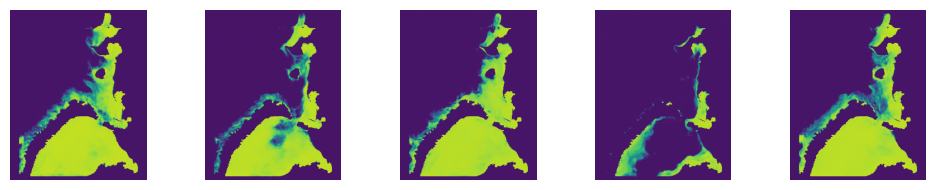

In [32]:
import matplotlib.colors as mcolors

rows, cols = 1, 5
n = rows * cols

imgs = [samples[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [150]:
import torch

def guided_flow_matching_step(
    model,
    x_t,
    t,
    y,
    mask,
    dt,
    guidance_scale=1.0,
    eps=1e-8
):

    device = x_t.device
    dtype = x_t.dtype
    batch_size = x_t.shape[0]

    y = y.to(device=device, dtype=dtype)
    mask = mask.to(device=device, dtype=dtype)
    if y.shape[0] == 1 and batch_size > 1:
        y = y.expand(batch_size, -1, -1, -1).contiguous()
    if mask.shape[0] == 1 and batch_size > 1:
        mask = mask.expand(batch_size, -1, -1, -1).contiguous()

    x_t = x_t.detach().to(device).requires_grad_(True)

    t_tensor = torch.full((batch_size,), float(t), device=device, dtype=dtype)
    grid_new = grid_eval.expand(batch_size, -1, -1, -1)

    with torch.enable_grad():
        out = model(torch.cat([x_t, grid_new], dim=1), t_tensor * 1000)
        v_t = out.sample

        x_hat_1 = x_t - t * v_t

        per_elem = (x_hat_1 * mask - y) ** 2
        loss_per_sample = per_elem.view(batch_size, -1).mean(dim=1)
        loss = loss_per_sample.mean()
        grad = torch.autograd.grad(loss, x_t, create_graph=False, retain_graph=False)[0]

        grad_flat = grad.view(batch_size, -1)
        grad_norm = torch.norm(grad_flat, dim=1).view(batch_size, 1, 1, 1)

    v_guided = v_t.detach() + guidance_scale * (grad.detach() / (grad_norm + eps))

    with torch.no_grad():
        x_next = x_t + v_guided * dt

    return x_next.detach()


def evaluate_with_condition(model, y, mask, num_timesteps, guidance_scale=1.0, device='cuda', batch_size=15):
    timesteps = [float(i) / num_timesteps for i in range(num_timesteps, 0, -1)]
    x = torch.randn((batch_size, 2, 320, 256), device=device)

    y = y.to(device)
    mask = mask.to(device)

    for t in timesteps:
        x = guided_flow_matching_step(
            model, x, t, y, mask, dt=-1.0 / num_timesteps,
            guidance_scale=guidance_scale
        )

    return x


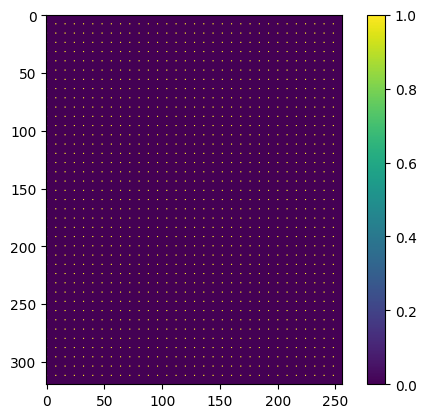

In [34]:
def create_sparse_mask_fixed(batch=1, channels=2, h=320, w=256, step=8):
    mask = torch.zeros((batch, channels, h, w), device = 'cuda')
    mask[:, :, ::step, ::step] = 1.0

    return mask

mask = create_sparse_mask_fixed(batch=1, channels=2, h=320, w=256, step=8)

plt.imshow(mask[0][0].detach().cpu())
plt.colorbar()
plt.show()


In [36]:
dataset_test = NpyImageDataset(
    folder='data_test/processed_ice_data_test',
    transform=channel_normalize,
    preload = False,
    mmap_mode = 'r'
)

In [37]:
N_conditional_samples = 10
originals = torch.stack([dataset_test[i*(len(dataset_test)//N_conditional_samples)] for i in range(N_conditional_samples)])

In [38]:
originals.shape

torch.Size([10, 2, 320, 256])

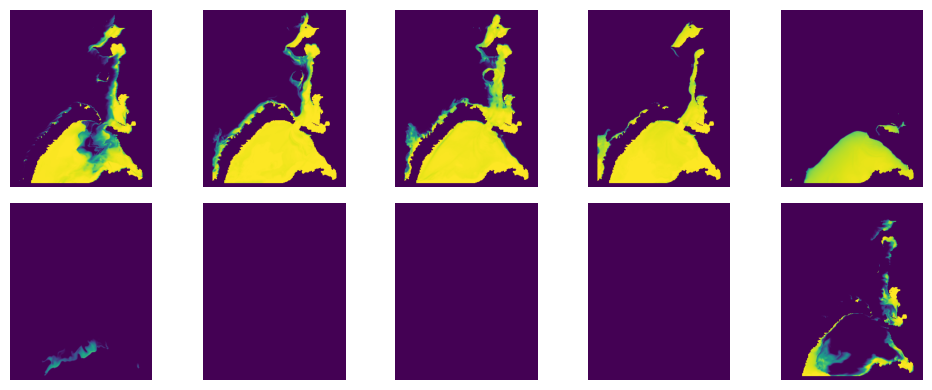

In [39]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [originals[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [40]:
y = originals*mask.detach().cpu()
y.shape

torch.Size([10, 2, 320, 256])

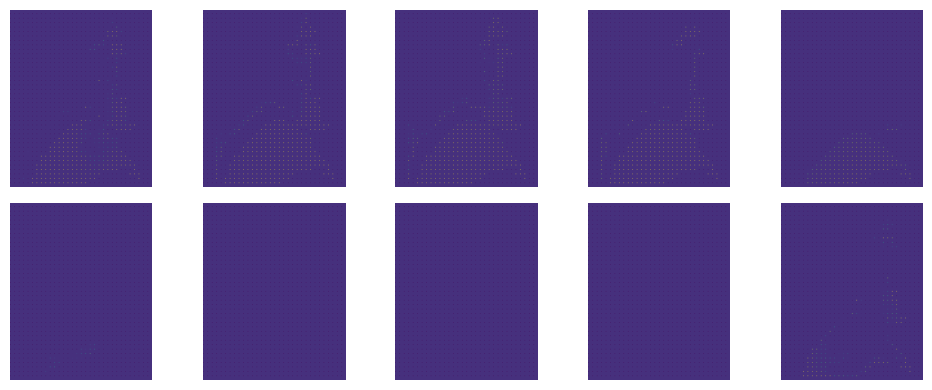

In [41]:
rows, cols = 2, 5
n = rows * cols
y_det = y.detach().cpu()

imgs = [y_det[i][0] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx]
    im = ax.imshow(img, norm=norm, cmap = 'viridis')
    ax.axis('off')
plt.tight_layout()
plt.show()


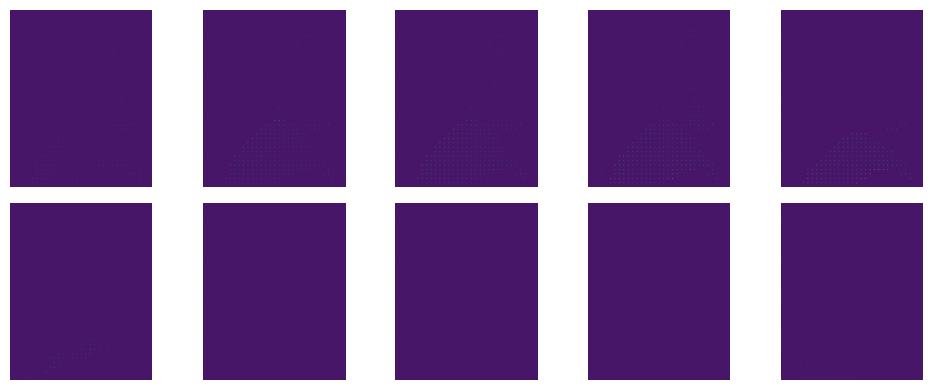

In [72]:
rows, cols = 2, 5
n = rows * cols
y_det = y.detach().cpu()

imgs = [y_det[i][1] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx]
    im = ax.imshow(img, norm=norm, cmap = 'viridis')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [42]:
mask.shape

torch.Size([1, 2, 320, 256])

In [43]:
y[:1].shape

torch.Size([1, 2, 320, 256])

In [44]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()


In [45]:
sample = evaluate_with_condition(model, y, mask, 200, guidance_scale=200.0, batch_size=10)

Conditioned samples

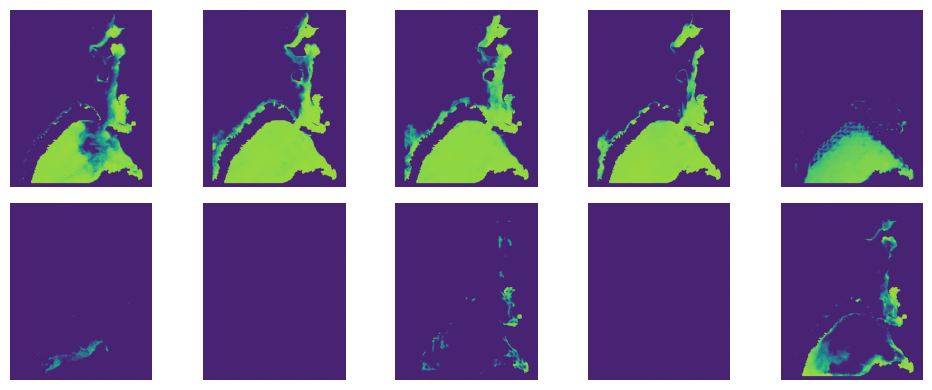

In [54]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [sample[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [55]:
print(sample.shape, originals.shape)
print(sample.device, originals.device)

torch.Size([10, 2, 320, 256]) torch.Size([10, 2, 320, 256])
cuda:0 cpu


Delta

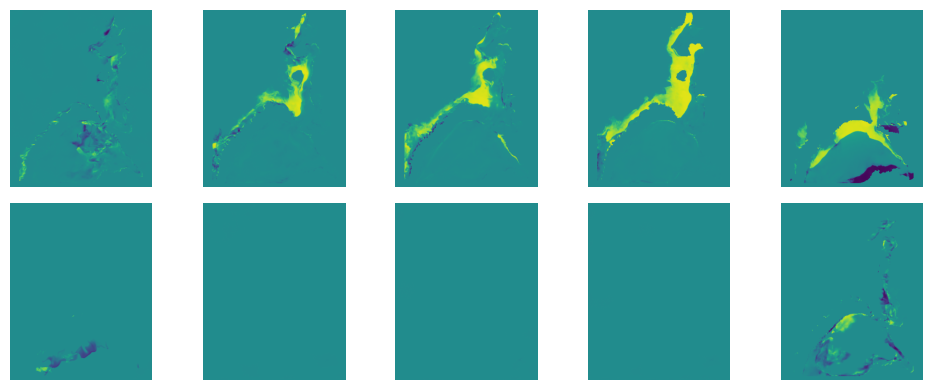

In [151]:
rows, cols = 2, 5
n = rows * cols

imgs = [(sample.detach().cpu() - originals)[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


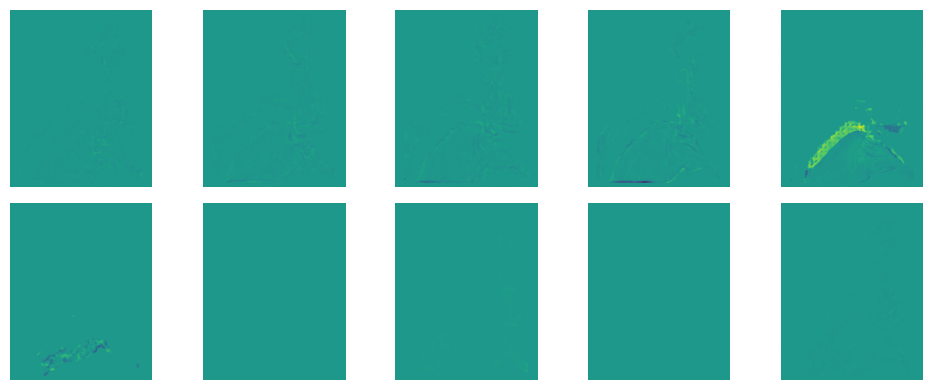

In [70]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [(sample.detach().cpu() - originals)[i][1].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


concentration error

In [57]:
for i in range(N_conditional_samples):
  print(torch.mean(((sample.detach().cpu() - originals)[i][0]*CHANNEL_STD[0])**2))

tensor(0.0025)
tensor(0.0048)
tensor(0.0048)
tensor(0.0073)
tensor(0.0081)
tensor(0.0011)
tensor(9.7140e-08)
tensor(0.0109)
tensor(9.3669e-08)
tensor(0.0044)


Thickness error

In [71]:
for i in range(N_conditional_samples):
  print(torch.mean(((sample.detach().cpu() - originals)[i][1]*CHANNEL_STD[1])**2))

tensor(0.0013)
tensor(0.0030)
tensor(0.0068)
tensor(0.0223)
tensor(0.0932)
tensor(0.0133)
tensor(1.0741e-06)
tensor(0.0006)
tensor(9.3377e-07)
tensor(0.0005)


### Comparison with images from dataset approximation

In [62]:
min_mse = 10
min_i = 0
mask_cpu = mask.detach().cpu()
for i in range(len(dataset)):
  mse = torch.mean((originals[9][0] - dataset[i][0])**2*mask_cpu).item()
  if mse < min_mse:
    min_mse = mse
    min_i = i
print(min_i)

8204


closets image from dataset

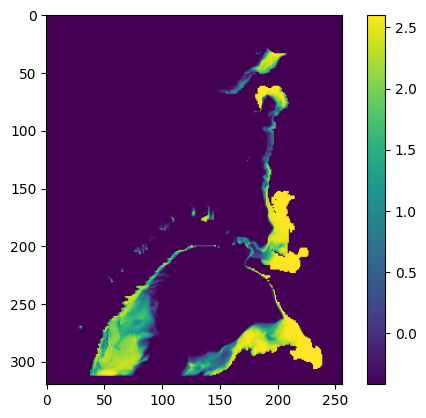

In [64]:
plt.imshow(dataset[min_i][0])
plt.colorbar()
plt.show()

In [76]:
my_sample = sample[9][0].detach().cpu()
print(torch.mean((dataset[min_i][0] - my_sample)**2)*CHANNEL_STD[0]**2)

tensor(0.0173)


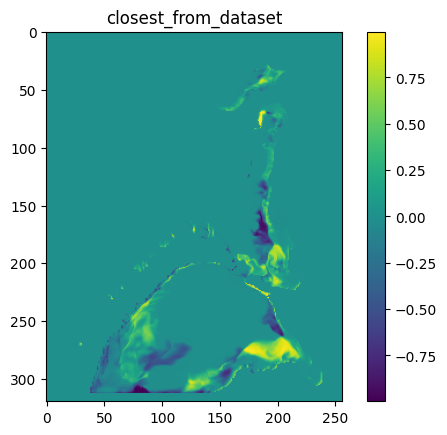

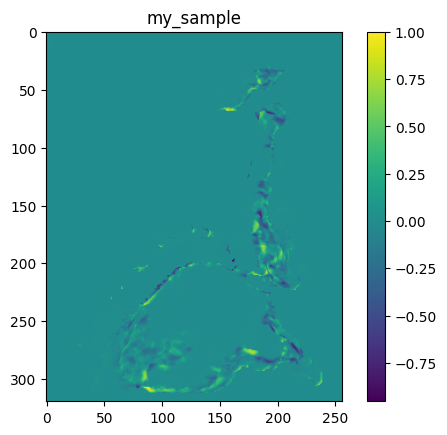

In [73]:
plt.imshow((dataset[min_i][0] - originals[9][0])*CHANNEL_STD[0])
plt.title('closest_from_dataset')
plt.colorbar()
plt.show()
plt.imshow((my_sample - originals[9][0])*CHANNEL_STD[0])
plt.title('my_sample')
plt.colorbar()
plt.show()

### Satellite tracks

In [79]:
satellite_tracks = satellite_tracks[:2]
satellite_tracks.shape

(2, 311, 225)

In [80]:
satellite_tracks_padded = np.pad(
    satellite_tracks,
    pad_width=((0, 0), (4, 5), (15, 16)),
    mode="constant"
)



In [92]:
track_mask = torch.from_numpy((np.nan_to_num(satellite_tracks_padded, nan = 0.0) != 0))

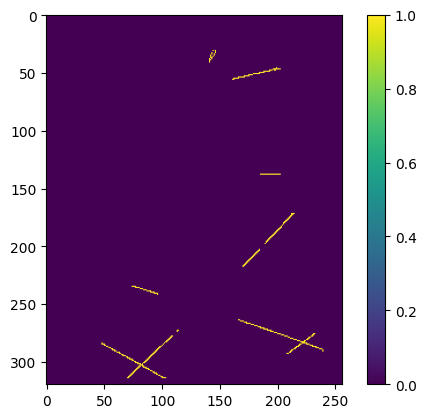

In [93]:
plt.imshow(track_mask[0])
plt.colorbar()
plt.show()

In [95]:
y = originals*track_mask
y.shape

torch.Size([10, 2, 320, 256])

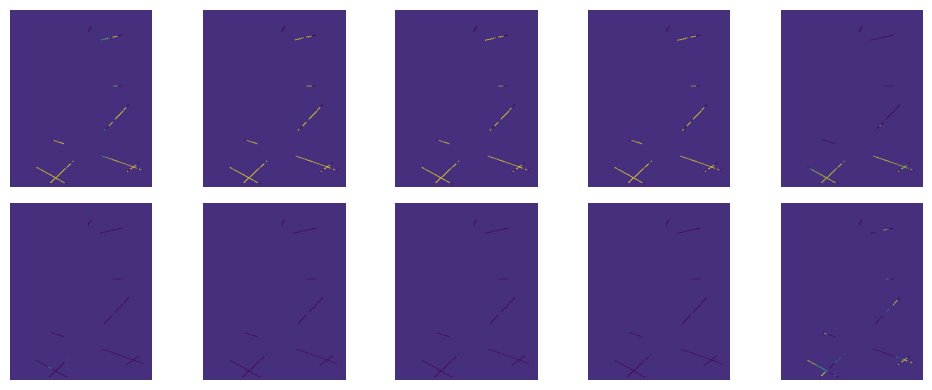

In [96]:
rows, cols = 2, 5
n = rows * cols
y_det = y.detach().cpu()

imgs = [y_det[i][0] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx]
    im = ax.imshow(img, norm=norm, cmap = 'viridis')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [152]:
track_samples = evaluate_with_condition(model, y, track_mask, 200, guidance_scale=200.0, batch_size=10)

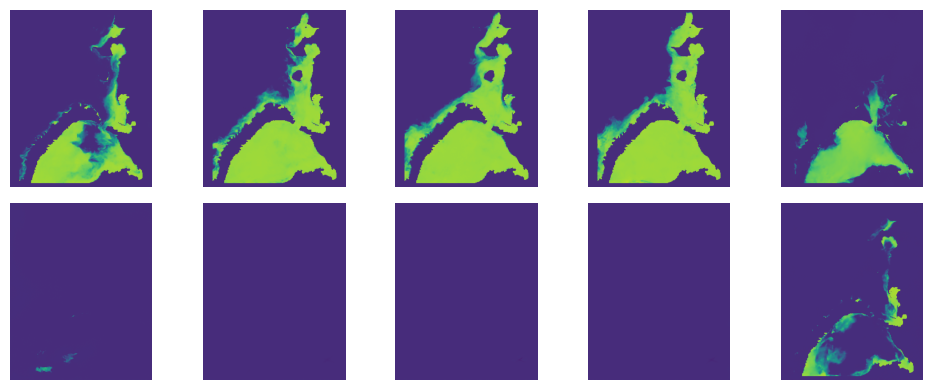

In [153]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [sample[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


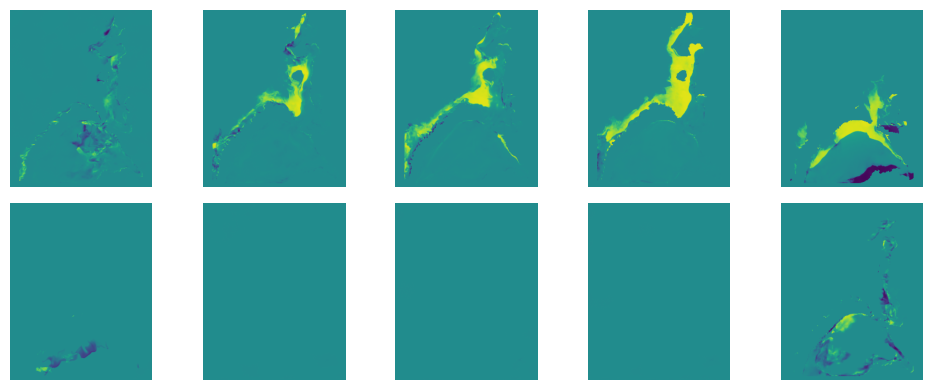

In [154]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [(sample.detach().cpu() - originals)[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [185]:
sample.shape

torch.Size([10, 2, 320, 256])

concentration error

In [155]:
for i in range(N_conditional_samples):
  print(torch.mean(((sample.detach().cpu() - originals)[i][0]*CHANNEL_STD[0])**2))

tensor(0.0069)
tensor(0.0253)
tensor(0.0345)
tensor(0.0645)
tensor(0.0490)
tensor(0.0028)
tensor(2.8510e-07)
tensor(3.9688e-07)
tensor(4.5501e-07)
tensor(0.0116)


thickness error

In [186]:
for i in range(N_conditional_samples):
  print(torch.mean(((sample.detach().cpu() - originals)[i][1]*CHANNEL_STD[1])**2))

tensor(0.0022)
tensor(0.0151)
tensor(0.0276)
tensor(0.0452)
tensor(0.2954)
tensor(0.0348)
tensor(7.5308e-07)
tensor(1.1918e-06)
tensor(9.8851e-07)
tensor(0.0018)


### Частичное зашумление


In [156]:
import torch

def correct_with_condition(approx_image , model, y, mask, num_timesteps, guidance_scale=1.0, device='cuda', batch_size=15, noise_val = 0.5):
    timesteps = [float(i) / num_timesteps for i in range(num_timesteps, 0, -1)]
    x, _ = add_noise(approx_image, torch.tensor([noise_val]))

    x = x.to(device)
    y = y.to(device)
    mask = mask.to(device)

    for t in timesteps:
        x = guided_flow_matching_step(
            model, x, t, y, mask, dt=-noise_val / num_timesteps,
            guidance_scale=guidance_scale
        )

    return x


In [157]:
N_conditional_samples = 10
originals = torch.stack([dataset_test[i*(len(dataset_test)//N_conditional_samples)] for i in range(N_conditional_samples)])

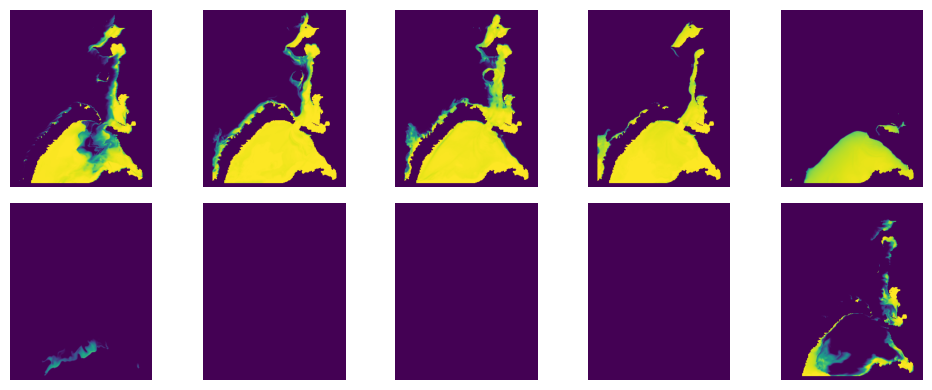

In [158]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [originals[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [161]:
N_conditional_samples = 10
approx_images = torch.stack([dataset_test[i*(len(dataset_test)//N_conditional_samples) + 120] for i in range(N_conditional_samples)])

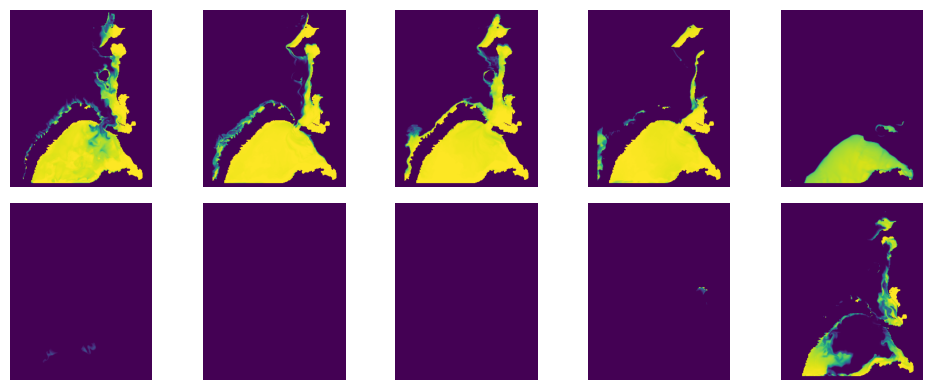

In [162]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [approx_images[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


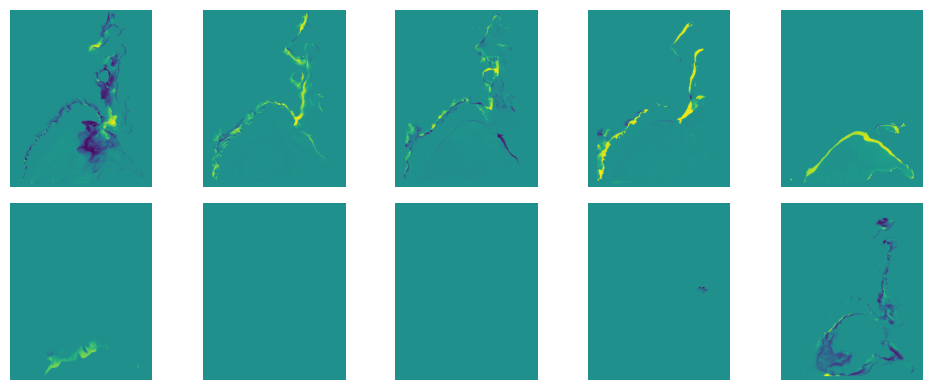

In [163]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [(originals - approx_images)[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [164]:
for i in range(N_conditional_samples):
  print(torch.mean(((approx_images - originals)[i][0]*CHANNEL_STD[0])**2))

tensor(0.0267)
tensor(0.0107)
tensor(0.0093)
tensor(0.0164)
tensor(0.0098)
tensor(0.0023)
tensor(0.)
tensor(0.)
tensor(0.0003)
tensor(0.0133)


In [178]:
corrected_sample = correct_with_condition(approx_images, model, y, track_mask, 200, guidance_scale=200.0, batch_size=10, noise_val = 0.8)

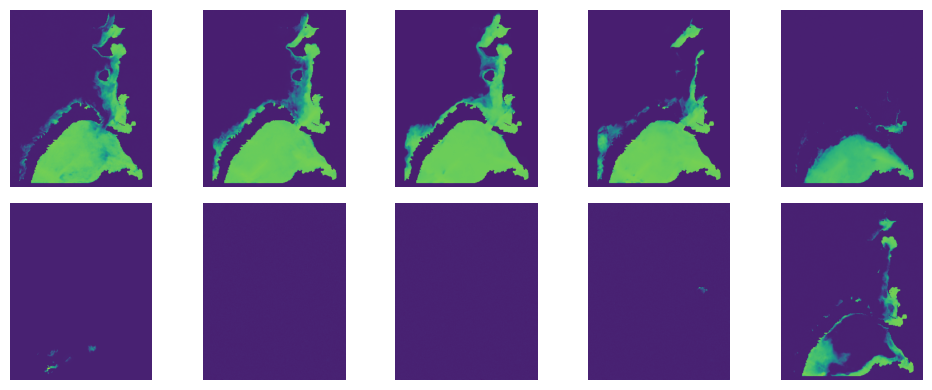

In [179]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [corrected_sample[i][0].detach().cpu() for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


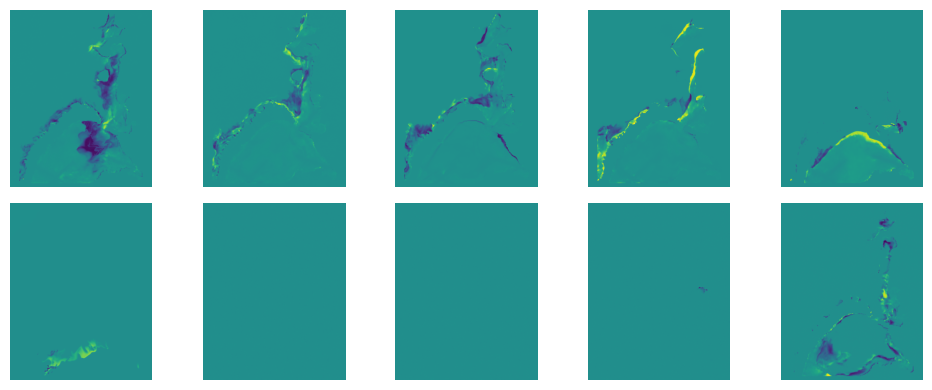

In [180]:
import matplotlib.colors as mcolors

rows, cols = 2, 5
n = rows * cols

imgs = [(originals - corrected_sample.detach().cpu())[i][0] for i in range(n)]
vmin = min(img.min().item() for img in imgs)
vmax = max(img.max().item() for img in imgs)


norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img = imgs[idx].numpy()
    im = ax.imshow(img, norm=norm)
    ax.axis('off')
plt.tight_layout()
plt.show()


corrected sample error

In [181]:
for i in range(N_conditional_samples):
  print(torch.mean(((corrected_sample.detach().cpu()- originals)[i][0]*CHANNEL_STD[0])**2))

tensor(0.0230)
tensor(0.0074)
tensor(0.0106)
tensor(0.0125)
tensor(0.0075)
tensor(0.0021)
tensor(5.9339e-05)
tensor(5.1083e-05)
tensor(0.0002)
tensor(0.0098)


initial error

In [182]:
for i in range(N_conditional_samples):
  print(torch.mean(((approx_images- originals)[i][0]*CHANNEL_STD[0])**2))

tensor(0.0267)
tensor(0.0107)
tensor(0.0093)
tensor(0.0164)
tensor(0.0098)
tensor(0.0023)
tensor(0.)
tensor(0.)
tensor(0.0003)
tensor(0.0133)


error without background state

In [184]:
for i in range(N_conditional_samples):
  print(torch.mean(((track_samples.detach().cpu() - originals)[i][0]*CHANNEL_STD[0])**2))

tensor(0.0103)
tensor(0.0429)
tensor(0.0290)
tensor(0.0647)
tensor(0.0392)
tensor(0.0030)
tensor(3.6356e-07)
tensor(2.0355e-07)
tensor(6.0152e-07)
tensor(0.0122)
